In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader
from pathlib import Path
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Будем использовать: {device}")

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

Будем использовать: cuda


In [4]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

data_dir = '../data/processed'

train_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(f'{data_dir}/val', transform=eval_transforms)
test_dataset = datasets.ImageFolder(f'{data_dir}/test', transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Данные готовы: Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

Данные готовы: Train 1798, Val 384, Test 391


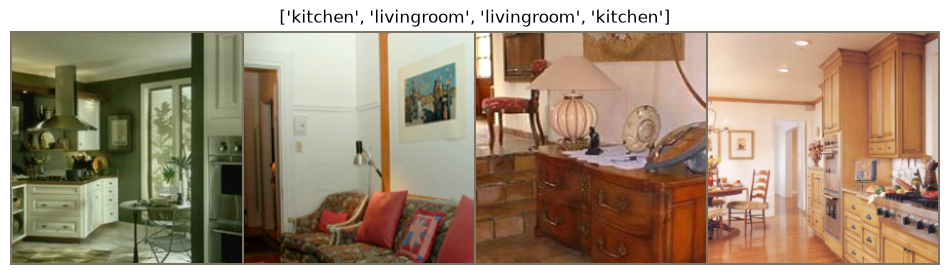

In [5]:
import numpy as np
def imshow(inp, title=None):
    """Функция для денормализации и показа тензора-картинки"""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = STD * inp + MEAN 
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

inputs, classes = next(iter(train_loader))

out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[train_dataset.classes[x] for x in classes[:4]])

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, 
                device="cpu", num_epochs=10, save_path="models/best_model.pth"):
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    best_val_acc = -1.0 
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    
    print(f"Старт | Девайс: {device} | Эпох: {num_epochs}\n" + "="*60)
    for epoch in range(num_epochs):
        start_time = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler:
            scheduler.step(val_loss) if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau) else scheduler.step()
                
        history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        elapsed = time.time() - start_time
        log = (f"Epoch {epoch+1:02d}/{num_epochs:02d} [{elapsed:.0f}s] | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.1f}% | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}% | "
            f"LR: {current_lr:.6f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({'model_state_dict': model.state_dict(), 'val_acc': val_acc}, save_path)
            print(log + " -> [Saved]")
        else:
            print(log)
    return history

In [8]:
model_baseline = models.resnet18(weights=ResNet18_Weights.DEFAULT)
for param in model_baseline.parameters():
    param.requires_grad = False
    
model_baseline.fc = nn.Linear(model_baseline.fc.in_features, 5)
model_baseline = model_baseline.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_baseline.fc.parameters(), lr=1e-3)
scheduler_base = optim.lr_scheduler.ReduceLROnPlateau(optimizer_base, mode='min', patience=2)

history_base = train_model(
    model_baseline, train_loader, val_loader, criterion, 
    optimizer_base, scheduler_base, device, num_epochs=10, 
    save_path="../models/best_baseline.pth"
)

Старт | Девайс: cuda | Эпох: 10
Epoch 01/10 [23s] | Train Loss: 1.2763  Acc: 48.2% | Val Loss: 0.9299 Acc: 66.9% | LR: 0.001000 -> [Saved]
Epoch 02/10 [22s] | Train Loss: 0.9896  Acc: 62.7% | Val Loss: 0.7548 Acc: 73.4% | LR: 0.001000 -> [Saved]
Epoch 03/10 [25s] | Train Loss: 0.8531  Acc: 67.9% | Val Loss: 0.7749 Acc: 69.3% | LR: 0.001000
Epoch 04/10 [22s] | Train Loss: 0.8469  Acc: 67.9% | Val Loss: 0.7680 Acc: 70.3% | LR: 0.001000
Epoch 05/10 [23s] | Train Loss: 0.8012  Acc: 68.9% | Val Loss: 0.7340 Acc: 72.1% | LR: 0.001000
Epoch 06/10 [24s] | Train Loss: 0.7838  Acc: 69.2% | Val Loss: 0.6779 Acc: 73.2% | LR: 0.001000
Epoch 07/10 [24s] | Train Loss: 0.7558  Acc: 71.5% | Val Loss: 0.5966 Acc: 77.9% | LR: 0.001000 -> [Saved]
Epoch 08/10 [22s] | Train Loss: 0.7887  Acc: 68.1% | Val Loss: 0.6980 Acc: 74.5% | LR: 0.001000
Epoch 09/10 [21s] | Train Loss: 0.7542  Acc: 69.2% | Val Loss: 0.5937 Acc: 76.8% | LR: 0.001000
Epoch 10/10 [22s] | Train Loss: 0.7548  Acc: 70.8% | Val Loss: 0.5772 A

In [9]:
for param in model_baseline.layer4.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam([
    {'params': model_baseline.layer4.parameters(), 'lr': 1e-4},
    {'params': model_baseline.fc.parameters(), 'lr': 1e-3}
])
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', patience=2)

history_ft = train_model(
    model_baseline, train_loader, val_loader, criterion, 
    optimizer_ft, scheduler_ft, device, num_epochs=10, 
    save_path="../models/best_finetuned.pth"
)

Старт | Девайс: cuda | Эпох: 10
Epoch 01/10 [25s] | Train Loss: 0.7463  Acc: 72.1% | Val Loss: 0.5972 Acc: 77.9% | LR: 0.000100 -> [Saved]
Epoch 02/10 [27s] | Train Loss: 0.5967  Acc: 76.8% | Val Loss: 0.4637 Acc: 83.6% | LR: 0.000100 -> [Saved]
Epoch 03/10 [25s] | Train Loss: 0.4966  Acc: 80.5% | Val Loss: 0.5060 Acc: 81.8% | LR: 0.000100
Epoch 04/10 [25s] | Train Loss: 0.4739  Acc: 82.3% | Val Loss: 0.5986 Acc: 77.9% | LR: 0.000100
Epoch 05/10 [25s] | Train Loss: 0.4588  Acc: 83.1% | Val Loss: 0.5626 Acc: 81.5% | LR: 0.000100
Epoch 06/10 [24s] | Train Loss: 0.3948  Acc: 85.0% | Val Loss: 0.5062 Acc: 84.1% | LR: 0.000010 -> [Saved]
Epoch 07/10 [24s] | Train Loss: 0.3409  Acc: 87.3% | Val Loss: 0.4999 Acc: 84.6% | LR: 0.000010 -> [Saved]
Epoch 08/10 [25s] | Train Loss: 0.3266  Acc: 88.6% | Val Loss: 0.4971 Acc: 84.4% | LR: 0.000010
Epoch 09/10 [23s] | Train Loss: 0.3188  Acc: 88.7% | Val Loss: 0.4864 Acc: 85.2% | LR: 0.000001 -> [Saved]
Epoch 10/10 [23s] | Train Loss: 0.3055  Acc: 88.9

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, title="История обучения"):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', marker='o', color='orange')
    plt.title(f'{title} — Функция потерь (Loss)')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    train_acc = [acc * 100 if acc <= 1 else acc for acc in history['train_acc']]
    val_acc = [acc * 100 if acc <= 1 else acc for acc in history['val_acc']]
    
    plt.plot(train_acc, label='Train Acc', marker='o', color='blue')
    plt.plot(val_acc, label='Val Acc', marker='o', color='orange')
    plt.title(f'{title} — Точность (Accuracy)')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность (%)')
    plt.grid(True)
    plt.legend()

    plt.show()

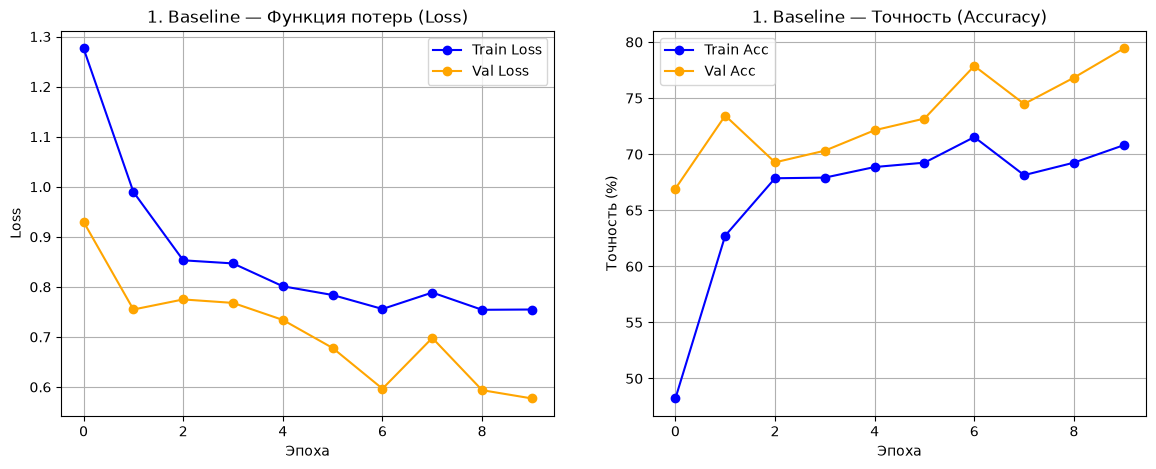

In [11]:
plot_training_history(history_base, title="1. Baseline")

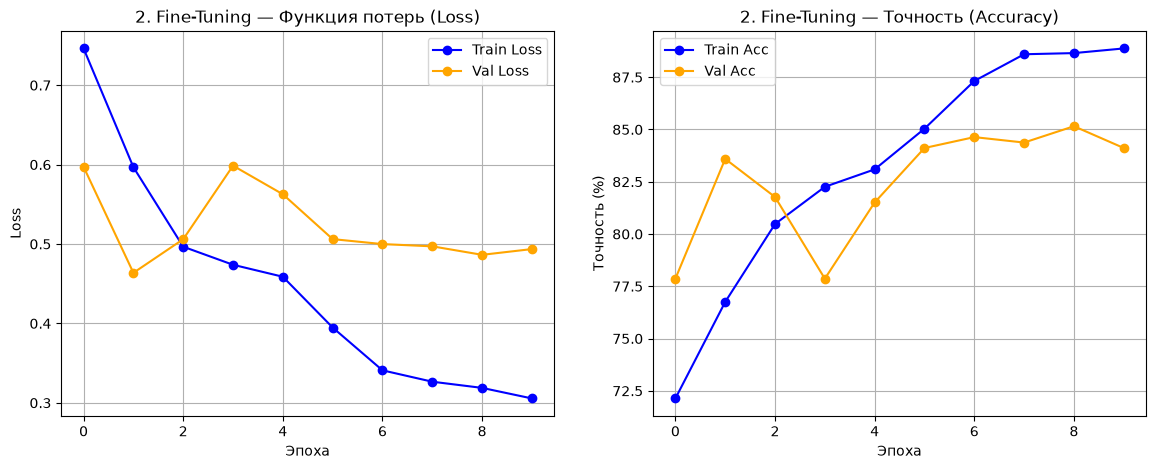

In [12]:
plot_training_history(history_ft, title="2. Fine-Tuning")

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test(model, weights_path, test_loader, device, class_names, title="Модель"):
    print(f"Оценка на тестовом сете: {title.upper()}")
    print("\n")

    checkpoint = torch.load(weights_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"Test Accuracy: {acc*100:.2f}% | Test Macro-F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    plt.figure(figsize=(7, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Предсказание модели')
    plt.ylabel('Истинный класс')
    plt.title(f'{title} — Confusion Matrix (Test Macro-F1: {macro_f1:.2f})')
    plt.show()
    
    return acc, macro_f1

class_names = test_dataset.classes


Оценка на тестовом сете: BASELINE (FROZEN RESNET18)


Test Accuracy: 76.98% | Test Macro-F1: 0.7609

              precision    recall  f1-score   support

    bathroom     0.9545    0.6774    0.7925        31
     bedroom     0.8193    0.6800    0.7432       100
 dining_room     0.8065    0.5952    0.6849        42
     kitchen     0.8443    0.9279    0.8841       111
  livingroom     0.6316    0.7850    0.7000       107

    accuracy                         0.7698       391
   macro avg     0.8112    0.7331    0.7609       391
weighted avg     0.7844    0.7698    0.7690       391



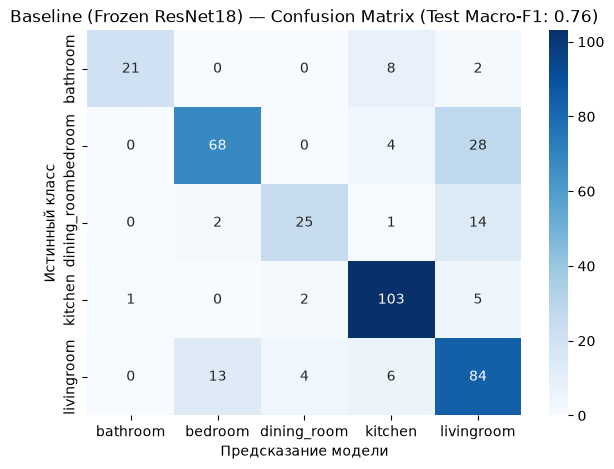

In [22]:
# 1. Тестируем BASELINE
base_acc, base_f1 = evaluate_model_on_test(
    model=model_baseline,
    weights_path="../models/best_baseline.pth", # поправь путь, если без ../
    test_loader=test_loader,
    device=device,
    class_names=class_names,
    title="Baseline (Frozen ResNet18)"
)

Оценка на тестовом сете: FINE-TUNED (LAYER4 + FC)


Test Accuracy: 82.61% | Test Macro-F1: 0.8174

              precision    recall  f1-score   support

    bathroom     0.9259    0.8065    0.8621        31
     bedroom     0.8681    0.7900    0.8272       100
 dining_room     0.6600    0.7857    0.7174        42
     kitchen     0.8750    0.9459    0.9091       111
  livingroom     0.7864    0.7570    0.7714       107

    accuracy                         0.8261       391
   macro avg     0.8231    0.8170    0.8174       391
weighted avg     0.8299    0.8261    0.8262       391



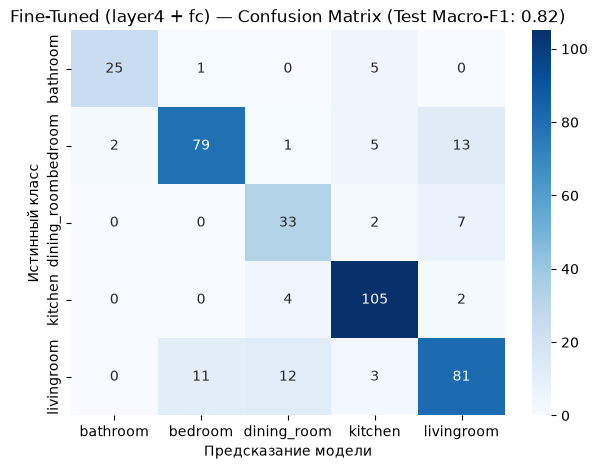

In [23]:
# 2. Тестируем FINE-TUNED
ft_acc, ft_f1 = evaluate_model_on_test(
    model=model_baseline,
    weights_path="../models/best_finetuned.pth", # поправь путь, если без ../
    test_loader=test_loader,
    device=device,
    class_names=class_names,
    title="Fine-Tuned (layer4 + fc)"
)

In [26]:
print("Финальное сравнение")
print("="*45)
print(f"{'Модель':<25} | {'Accuracy':<10} | {'Macro F1':<10}")
print("-"*45)
print(f"{'Baseline (Frozen)':<25} | {base_acc*100:.2f}%     | {base_f1:.4f}")
print(f"{'Fine-Tuning (layer4)':<25} | {ft_acc*100:.2f}%     | {ft_f1:.4f}")
print("="*45)

Финальное сравнение
Модель                    | Accuracy   | Macro F1  
---------------------------------------------
Baseline (Frozen)         | 76.98%     | 0.7609
Fine-Tuning (layer4)      | 82.61%     | 0.8174
